# **2/2568 FRA501: Pattern Recognition**
## **HW3 GMM, PCA and LDA**

**Member**
- 65340500037 Pavaris Asawakijtananont
- 65340500058 Anuwit Intet
- 65340500062 Aitthikit Kitchareonnon

### 3.1 Hello Soft Clustering (GMM)

Recall from HW1 we did K-means clustering. Fitting a GMM on a set of points can be considered
as another method to do clustering but now with soft assignments. Consider the same set of
points we used in HW1.

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import multivariate_normal

In [73]:
X = np.array([[1, 2], [3, 3], [2, 2], [8, 8], [6, 6], [7, 7], [-3, -3], [-2, -4], [-7, -7]])

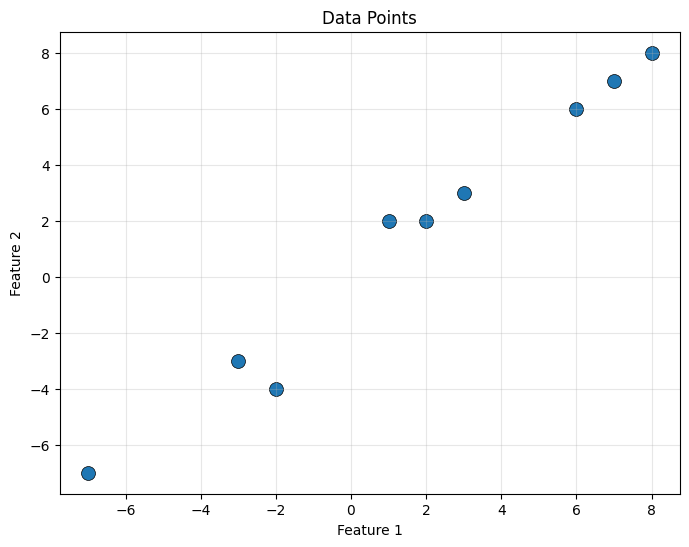

In [74]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=100, edgecolors='k', linewidths=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data Points')
plt.grid(True, alpha=0.3)
plt.show()

### Initialization: 
Initialize the mixture weights, $\phi = {m_j}$ , where $j$ is the mixture number, means of each Gaussian $\mu_j$ (now a vector of N dimensions), and covariance matrices of each Gaussian $\Sigma_j$

In [75]:
n_samples, n_features = X.shape
k = 3

# Initialization
mu = np.array([[3.0, 3.0], [2.0, 2.0], [-3.0, -3.0]])
sigma = [np.eye(n_features) for _ in range(k)]
phi = np.array([1/3, 1/3, 1/3]) # Initial equal mixing coefficients at 1/3
w = np.zeros((n_samples, k))

### Visualization helper function: 
This function create for visualize likelihood distributions in each EM step

In [76]:
def draw_confidence_ellipse(ax, mean, cov, n_std=2.0, color='blue', alpha=0.15, label=None):
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    # Rotation angle from the largest eigenvector
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    
    # Width and height are 2 * n_std * sqrt(eigenvalue)
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    # Filled region (1σ)
    ellipse_fill = patches.Ellipse(
        xy=mean, width=width, height=height, angle=angle,
        facecolor=color, alpha=alpha, edgecolor='none'
    )
    ax.add_patch(ellipse_fill)
    
    # Solid border (1σ)
    ellipse_border = patches.Ellipse(
        xy=mean, width=width, height=height, angle=angle,
        facecolor='none', edgecolor=color, linewidth=1.5, alpha=0.8
    )
    ax.add_patch(ellipse_border)
    
    # Dashed 2σ border
    ellipse_2std = patches.Ellipse(
        xy=mean, width=width * 2, height=height * 2, angle=angle,
        facecolor='none', edgecolor=color, linewidth=0.8, alpha=0.4, label=label
    )
    ax.add_patch(ellipse_2std)

### Part 1
Using 3 mixtures, initialize your Gaussian with means (3,3), (2,2), and (-3,-3), 
and standard Covariance, I, the identity matrix. Use equal mixture weights as the initial weights.
Repeat three iterations of EM. Write down $w_{n,j}$
, $m_j$
, $μ_j$
, $Σ_j$ and plot the likelihood distributions (3
Gaussians) of each feature for each EM iteration. (You may do the calculations by hand or write
code to do so) (5 points)


EM Iteration 1

Mixture weights φ_j: [0.33333333 0.33333333 0.33333333]
Effective counts n_j: [4.11815177 1.88184822 3.        ]

--- Component 1 ---
μ_0 = [5.78992692 5.81887265]
Σ_0 =
[[4.53619512 4.39754618]
 [4.39754618 4.28700711]]

--- Component 2 ---
μ_1 = [1.67718211 2.14523106]
Σ_1 =
[[0.51645679 0.19950142]
 [0.19950142 0.13152718]]

--- Component 3 ---
μ_2 = [-4.         -4.66666666]
Σ_2 =
[[4.66666768 3.33333335]
 [3.33333335 2.88888991]]

w_{n,j} :
[[1.02323097e-007 9.99998209e-001 1.68833582e-006]
 [8.52834210e-001 1.47163820e-001 1.96943634e-006]
 [2.41704032e-001 7.58273311e-001 2.26569142e-005]
 [1.00000000e+000 9.21930093e-064 3.71031806e-015]
 [1.00000000e+000 1.17067306e-027 1.72747323e-011]
 [1.00000000e+000 7.62735307e-044 2.68209106e-013]
 [5.46407507e-004 3.61305390e-053 9.99453592e-001]
 [3.86175684e-049 3.18090567e-094 1.00000000e+000]
 [6.42292692e-009 5.22504416e-165 9.99999994e-001]]
Log-Likelihood: -25.1523

EM Iteration 2

Mixture weights φ_j: [0.4575724

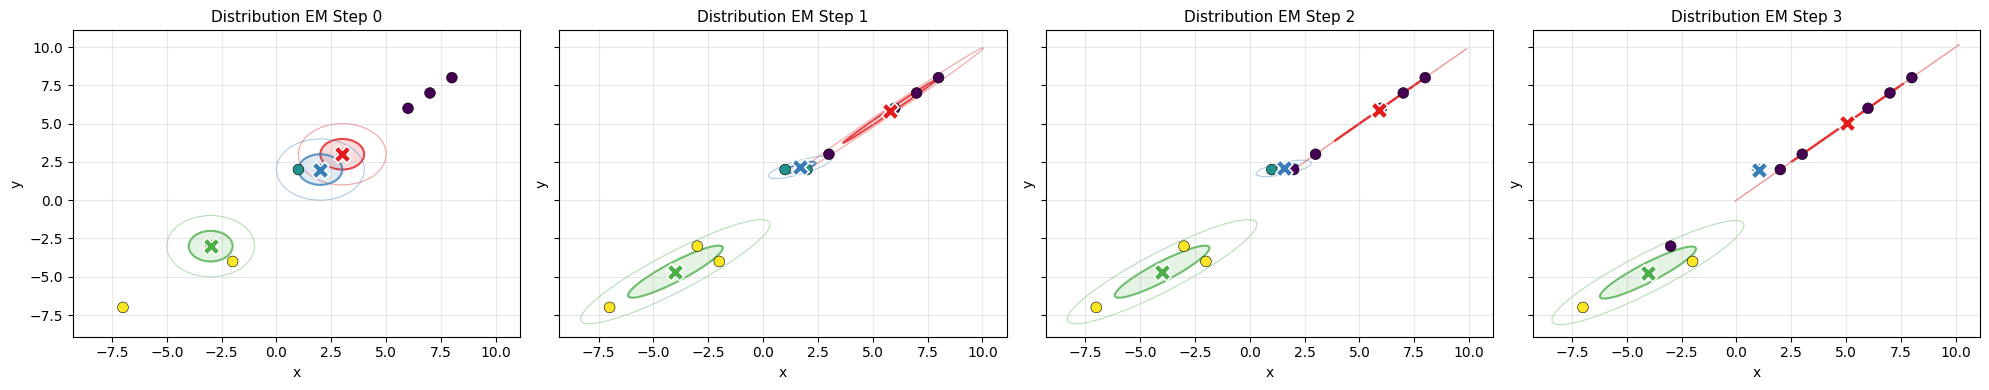

In [77]:
def mvn_pdf(x, mean, cov):
    n = len(mean)
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    diff = x - mean
    exponent = -0.5 * (diff @ inv @ diff.T)
    return (1.0 / np.sqrt(((2 * np.pi) ** n) * det)) * np.exp(exponent)

def compute_responsibilities(X, mu, sigma, phi):
    n_samples = X.shape[0]
    k = len(phi)
    w = np.zeros((n_samples, k))
    for i in range(n_samples):
        for j in range(k):
            w[i, j] = phi[j] * mvn_pdf(X[i], mu[j], sigma[j])
        w[i, :] /= np.sum(w[i, :])
    return w


history = []
w = compute_responsibilities(X, mu, sigma, phi)
history.append((0, mu.copy(), sigma.copy(), phi.copy(), np.argmax(w, axis=1)))

initial_ll = sum(np.log(sum(phi[j] * mvn_pdf(x, mu[j], sigma[j]) for j in range(k))) for x in X)
log_likelihoods = [initial_ll]


for step in range(1, 4):
    n_j = np.sum(w, axis=0)
    print(f"\n{'='*50}")
    print(f"EM Iteration {step}")
    print(f"{'='*50}")

    print(f"\nMixture weights φ_j: {phi}")
    print(f"Effective counts n_j: {n_j}")
    for j in range(k):
        phi[j] = n_j[j] / n_samples
        mu[j] = (w[:, j] @ X) / n_j[j]
        diff = X - mu[j]
        sigma[j] = (w[:, j] * diff.T @ diff) / n_j[j] + np.eye(n_features) * 1e-6
        print(f"\n--- Component {j+1} ---")
        print(f"μ_{j} = {mu[j]}")
        print(f"Σ_{j} =\n{sigma[j]}")
    w = compute_responsibilities(X, mu, sigma, phi)
    history.append((step, mu.copy(), sigma.copy(), phi.copy(), np.argmax(w, axis=1)))
    ll = sum(np.log(sum(phi[j] * mvn_pdf(x, mu[j], sigma[j]) for j in range(k))) for x in X)
    log_likelihoods.append(ll)
    print(f"\nw_{{n,j}} :\n{w}")
    print(f"Log-Likelihood: {ll:.4f}")

# --- Plotting with ellipses ---
colors = plt.cm.Set1.colors  # one distinct color per cluster
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True, sharey=True)

for ax, (step, mu_step, sigma_step, phi_step, labels_step) in zip(axes, history):
    ax.scatter(X[:, 0], X[:, 1], c=labels_step, cmap='viridis',
               s=60, edgecolors='k', linewidths=0.4, zorder=3)
    
    for j in range(k):
        color = colors[j % len(colors)]
        # Draw 1σ and 2σ confidence ellipses
        draw_confidence_ellipse(ax, mu_step[j], sigma_step[j],
                                n_std=1.0, color=color, alpha=0.15)
        # Mean marker
        ax.scatter(mu_step[j, 0], mu_step[j, 1],
                   marker='X', s=150, color=color,
                   edgecolors='white', linewidths=1.2, zorder=4)
    
    ax.set_title(f"Distribution EM Step {step}", fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
labels = np.argmax(w, axis=1)
plt.tight_layout()
plt.show()

1. $w_{n,j}$ Responsibilities (E-step output)
The probability that data point $n$ belongs to component $j$.

| Point | Comp 1 | Comp 2 | Comp 3 | Interpretation |
|:-----:|:------:|:------:|:------:|:---------------|
| 0 | ~0% | **~100%** | ~0% | Firmly belongs to component 2 |
| 1 | **85%** | 15% | ~0% | **Uncertain** — split between comp 1 and 2 |
| 6 | ~0% | ~0% | **~100%** | Firmly belongs to component 3 |

**What changes across iterations:**

| Iteration | Character | Meaning |
|:---------:|:---------:|:--------|
| 1 | Soft (some 85/15 splits) | Model still uncertain |
| 2 | Nearly hard (mostly 0 or 1) | Model gaining confidence |
| 3 | Fully hard (exact 0 or 1) | Collapsed — degenerate |

2. $n_j$ (effective counts) — Bridge between E-step and M-step
The "soft" count of how many points belong to component $j$. Not an integer — it's the sum of responsibilities across all points.

**Values across iterations:**

| | Comp 1 | Comp 2 | Comp 3 | Sum |
|:---:|:------:|:------:|:------:|:---:|
| Iter 1 | 4.12 | 1.88 | 3.00 | **9.00** ✓ |
| Iter 2 | 4.10 | 1.91 | 3.00 | **9.01** ✓ |
| Iter 3 | 5.07 | **1.03** | 2.90 | **9.00** ✓ |

3. $\phi_j$ — Mixture Weights (M-step output)

**Values across iterations:**

| | Comp 1 | Comp 2 | Comp 3 | Sum |
|:---:|:------:|:------:|:------:|:---:|
| Init | 0.333 | 0.333 | 0.333 | 1.0 |
| Iter 1 | 0.333 | 0.333 | 0.333 | 1.0 |
| Iter 2 | **0.458** | 0.209 | 0.333 | 1.0 |
| Iter 3 | 0.455 | 0.212 | 0.333 | 1.0 |

4. $\mu_j$ — Component Means (M-step output)

**Convergence story:**

| | Init | Iter 1 | Iter 2 | Iter 3 |
|:---|:----:|:------:|:------:|:------:|
| **Comp 1** | (3.0, 3.0) | (5.79, 5.82) | (5.87, 5.87) | (5.05, 5.05) |
| **Comp 2** | (3.0, 3.0) | (1.68, 2.15) | (1.55, 2.08) | **(1.03, 2.00)** ← collapse |
| **Comp 3** | (3.0, −3.0) | (−4.00, −4.67) | (−4.00, −4.67) | (−4.04, −4.73) ✓ |

- **Component 1** jumps from (3,3) → (5.87, 5.87) in one step, nearly finding the true cluster immediately.  
- **Component 2** drifts toward a single data point by iteration 3 — the mean is being pulled to one observation.  
- **Component 3** stabilizes after iteration 1 and barely moves — the cleanest, most well-separated cluster.

5. $\Sigma_j$ — Component Covariances (M-step output)

**Component 2 collapse in detail:**

| | $\sigma_x^2$ | $\sigma_y^2$ | $\sigma_{xy}$ | Shape |
|:---:|:------------:|:------------:|:-------------:|:-----:|
| Iter 1 | 0.516 | 0.132 | 0.200 | Small ellipse |
| Iter 2 | 0.402 | 0.071 | 0.112 | Shrinking fast |
| Iter 3 | **0.029** | **0.000073** | 0.000141 | **Near-zero spike** ← singularity |



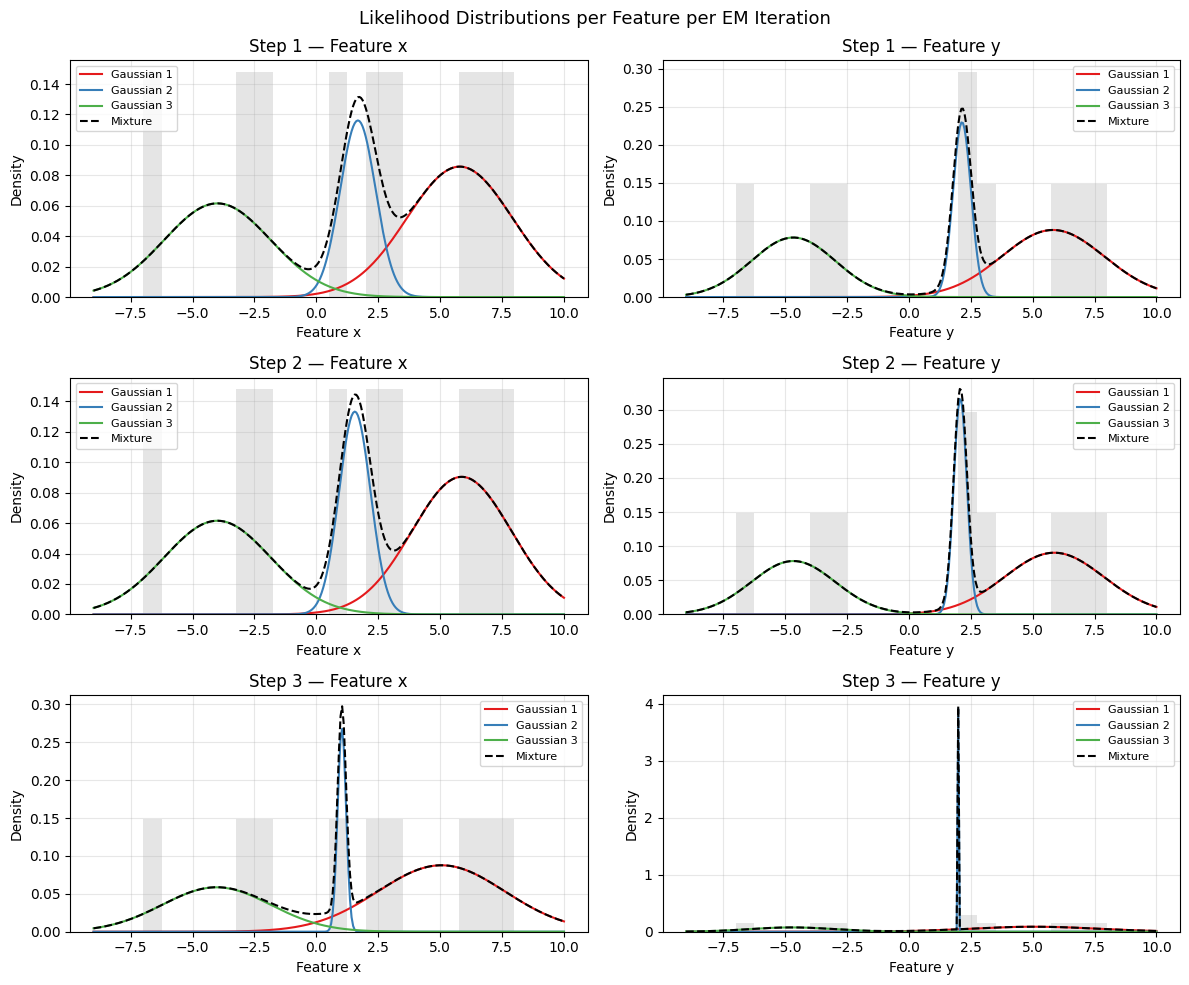

In [78]:
from scipy.stats import norm

fig, axes = plt.subplots(3, 2, figsize=(12, 10))  # 3 iterations × 2 features

for idx, (step, mu_step, sigma_step, phi_step, _) in enumerate(history[1:]):  # skip step 0
    for feat_idx, feat_name in enumerate(["Feature x", "Feature y"]):
        ax = axes[idx][feat_idx]
        x_range = np.linspace(X[:, feat_idx].min() - 2, X[:, feat_idx].max() + 2, 300)

        for j in range(k):
            mean_j  = mu_step[j][feat_idx]
            std_j   = np.sqrt(sigma_step[j][feat_idx, feat_idx])  # marginal std
            weight_j = phi_step[j]
            y_vals  = weight_j * norm.pdf(x_range, mean_j, std_j)
            ax.plot(x_range, y_vals, label=f"Gaussian {j+1}", color=colors[j])

        # Total mixture
        total = sum(
            phi_step[j] * norm.pdf(x_range, mu_step[j][feat_idx],
                                   np.sqrt(sigma_step[j][feat_idx, feat_idx]))
            for j in range(k)
        )
        ax.plot(x_range, total, 'k--', label="Mixture", linewidth=1.5)
        ax.hist(X[:, feat_idx], bins=20, density=True, alpha=0.2, color='gray')
        ax.set_title(f"Step {step} — {feat_name}")
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Likelihood Distributions per Feature per EM Iteration", fontsize=13)
plt.tight_layout()
plt.show()

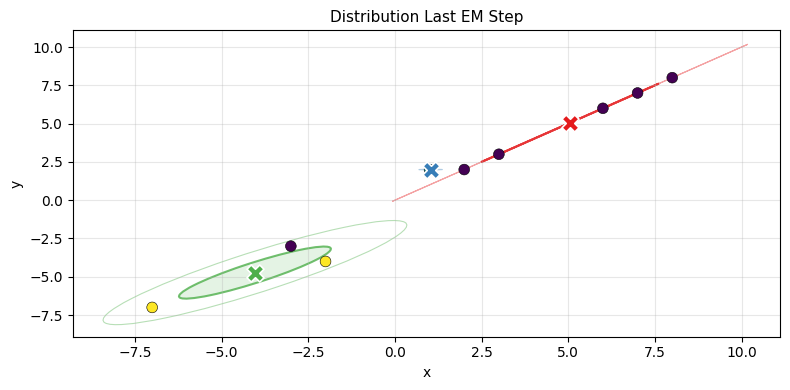

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex=True, sharey=True)
ax.scatter(X[:, 0], X[:, 1], c=labels_step, cmap='viridis',
               s=60, edgecolors='k', linewidths=0.4, zorder=3)
for j in range(k):
    color = colors[j % len(colors)]
    # Draw 1σ and 2σ confidence ellipses
    draw_confidence_ellipse(ax, mu_step[j], sigma_step[j],
                            n_std=1.0, color=color, alpha=0.15)
    # Mean marker
    ax.scatter(mu_step[j, 0], mu_step[j, 1],
                marker='X', s=150, color=color,
                edgecolors='white', linewidths=1.2, zorder=4)

ax.set_title(f"Distribution Last EM Step", fontsize=11)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Part 2 
Plot the log likelihood of the model given the data after each EM step. Does it goes up
every iteration just as we learned in class? (3 points)


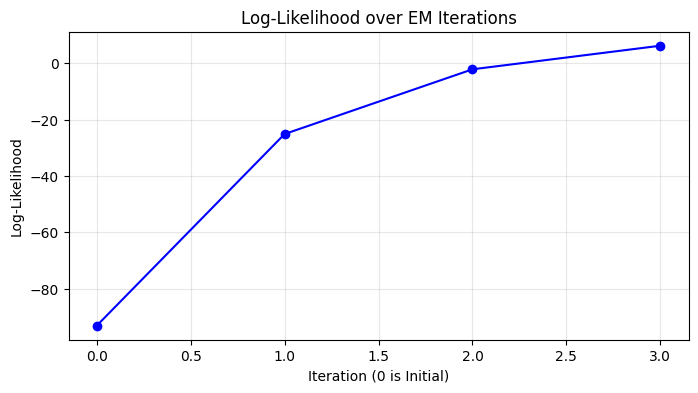

Log-Likelihoods: [np.float64(-93.17390123755949), np.float64(-25.152276555206537), np.float64(-2.1822488868411547), np.float64(6.186369895775084)]


In [80]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(log_likelihoods)), log_likelihoods, marker='o', linestyle='-', color='b')
plt.title("Log-Likelihood over EM Iterations")
plt.xlabel("Iteration (0 is Initial)")
plt.ylabel("Log-Likelihood")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Log-Likelihoods: {log_likelihoods}")

`ANSWER` : Yes, the log-likelihood goes up every iteration. Because the M-step is explicitly designed to maximize the parameters based on the current data assignments, every single cycle is mathematically forced to find a configuration that is at least as good, or better, than the previous one.

#### Part 3
Using 2 mixtures, initialize your Gaussian with means (3,3), and (3,-3), and standard
Covariance, I, the identity matrix. Use equal mixture weights as the initial weights. Repeat three
iterations of EM.Write down $w_{n,j}$
, $m_j$
, $μ_j$
, $Σ_j$ and plot the likelihood distributions (2 Gaussians) of each feature for each EM iteration. (5 points)

In [81]:
k_2 = 2

# Initialization
mu_2 = np.array([[3.0, 3.0], [-3.0, -3.0]])
sigma_2 = [np.eye(n_features) for _ in range(k_2)]
phi_2 = np.array([1/2, 1/2])

# Responsibilities (soft assignments) matrix
w_2 = np.zeros((n_samples, k_2))


EM Iteration 1

Mixture weights φ_j: [0.5 0.5]
Effective counts n_j: [5.99999998 3.00000002]

--- Component 1 ---
μ_0 = [4.50000001 4.66666667]
Σ_0 =
[[6.91666765 6.33333333]
 [6.33333333 5.88888989]]

--- Component 2 ---
μ_1 = [-3.99999997 -4.66666663]
Σ_1 =
[[4.66666777 3.33333349]
 [3.33333349 2.8888901 ]]

w_{n,j} 
[[9.99982837e-01 1.71625042e-05]
 [9.99997675e-01 2.32548115e-06]
 [9.99929131e-01 7.08685499e-05]
 [1.00000000e+00 9.16642461e-15]
 [1.00000000e+00 3.31755245e-11]
 [1.00000000e+00 5.94736051e-13]
 [5.15088493e-03 9.94849115e-01]
 [7.18159054e-19 1.00000000e+00]
 [5.58682725e-07 9.99999441e-01]]
Log-Likelihood: -31.1265

EM Iteration 2

Mixture weights φ_j: [0.66666666 0.33333334]
Effective counts n_j: [6.00506109 2.99493891]

--- Component 1 ---
μ_0 = [4.49360584 4.66012918]
Σ_0 =
[[6.9589489  6.37718098]
 [6.37718098 5.93420838]]

--- Component 2 ---
μ_1 = [-4.00154324 -4.66933076]
Σ_1 =
[[4.67386302 3.33727361]
 [3.33727361 2.89033826]]

w_{n,j} 
[[9.99983160e-01 1.

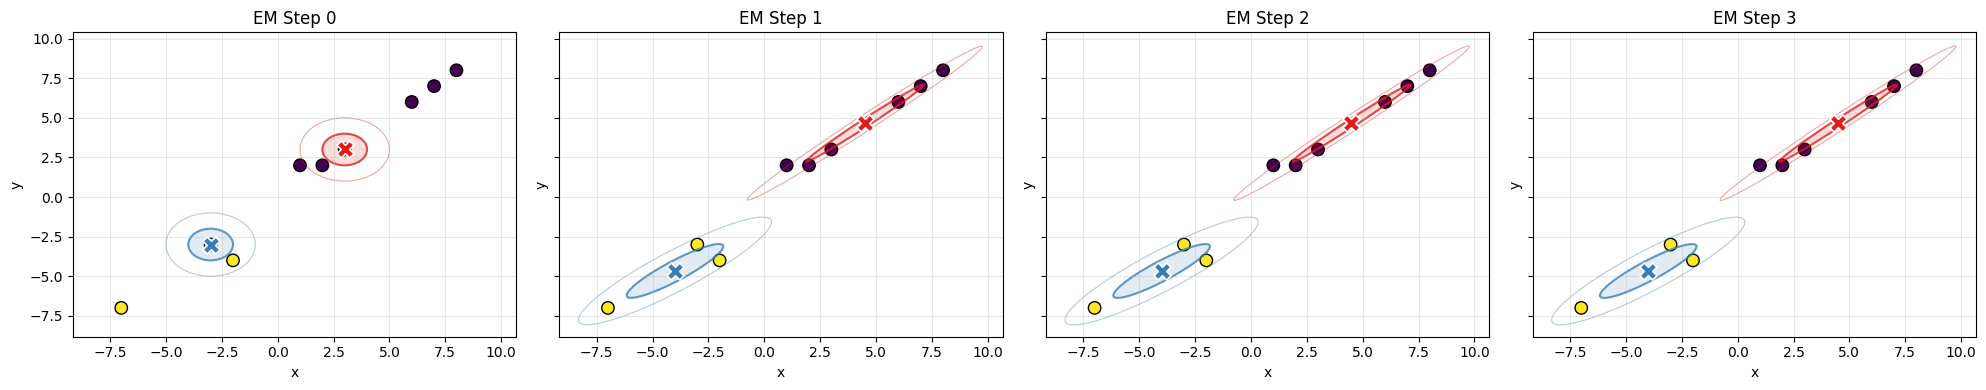

In [82]:
history_2 = []
w_2 = compute_responsibilities(X, mu_2, sigma_2, phi_2)
history_2.append((0, mu_2.copy(), sigma_2.copy(), phi_2.copy(), np.argmax(w_2, axis=1)))
# Calculate initial Log-Likelihood before any updates
initial_ll_2 = sum(np.log(sum(phi_2[j] * mvn_pdf(x, mu_2[j], sigma_2[j]) for j in range(k_2))) for x in X)
log_likelihoods_2 = []
log_likelihoods_2.append(initial_ll_2)

for step in range(1, 4):
    n_j = np.sum(w_2, axis=0)
    print(f"\n{'='*50}")
    print(f"EM Iteration {step}")
    print(f"{'='*50}")

    print(f"\nMixture weights φ_j: {phi_2}")
    print(f"Effective counts n_j: {n_j}")
    for j in range(k_2):
        phi_2[j] = n_j[j] / n_samples
        mu_2[j] = (w_2[:, j] @ X) / n_j[j]
        diff = X - mu_2[j]
        sigma_2[j] = (w_2[:, j] * diff.T @ diff) / n_j[j] + np.eye(n_features) * 1e-6
        print(f"\n--- Component {j+1} ---")
        print(f"μ_{j} = {mu_2[j]}")
        print(f"Σ_{j} =\n{sigma_2[j]}")
    w_2 = compute_responsibilities(X, mu_2, sigma_2, phi_2)
    history_2.append((step, mu_2.copy(), sigma_2.copy(), phi_2.copy(), np.argmax(w_2, axis=1)))
    ll = sum(np.log(sum(phi_2[j] * mvn_pdf(x, mu_2[j], sigma_2[j]) for j in range(k_2))) for x in X)
    log_likelihoods_2.append(ll)
    print(f"\nw_{{n,j}} \n{w_2}")
    print(f"Log-Likelihood: {ll:.4f}")

# Plot cluster assignments at each step
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True, sharey=True)
for ax, (step, mu_step, sigma_step, phi_step, labels_step) in zip(axes, history_2):
    ax.scatter(X[:, 0], X[:, 1], c=labels_step, cmap='viridis', s=80, edgecolors='k')
    for j in range(k_2):
        # ax.scatter(mu_step[j, 0], mu_step[j, 1], marker='X', s=150, c=f'C{j}', edgecolors='white')
        color = colors[j % len(colors)]
        # Draw 1σ and 2σ confidence ellipses
        draw_confidence_ellipse(ax, mu_step[j], sigma_step[j],
                                n_std=1.0, color=color, alpha=0.15)
        # draw_confidence_ellipse(ax, mu_step[j], sigma_step[j],
        #                         n_std=2.0, color=color, alpha=0.05)
        # Mean marker
        ax.scatter(mu_step[j, 0], mu_step[j, 1],
                   marker='X', s=150, color=color,
                   edgecolors='white', linewidths=1.2, zorder=4)
    ax.set_title(f"EM Step {step}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
labels = np.argmax(w_2, axis=1)
plt.tight_layout()
plt.show()

1. $w_{n,j}$ — Responsibilities (E-step output)
The probability that data point $n$ belongs to component $j$.

| Point | Comp 1 | Comp 2 | Interpretation |
|:-----:|:------:|:------:|:---------------|
| 0 | **~100%** | ~0% | Firmly belongs to component 1 |
| 1 | **~100%** | ~0% | Firmly belongs to component 1 |
| 6 | 0.52% | **~99.5%** | Mostly component 2, slight uncertainty |
| 7 | ~0% | **~100%** | Firmly belongs to component 2 |
| 8 | ~0% | **~100%** | Firmly belongs to component 2 |

**What changes across iterations:**

| Iteration | Character | Meaning |
|:---------:|:---------:|:--------|
| 1 | Nearly hard (already close to 0/1) | Model confident from the start |
| 2 | Hard (converging) | Responsibilities barely change |
| 3 | Hard (stable) | Model has converged — assignments frozen |

2. $n_j$ (effective counts) — Bridge between E-step and M-step
The "soft" count of how many points belong to component $j$. Not an integer — it's the sum of responsibilities across all points.

**Values across iterations:**

| | Comp 1 | Comp 2 | Sum |
|:---:|:------:|:------:|:---:|
| Iter 1 | 6.000 | 3.000 | **9.000** ✓ |
| Iter 2 | 6.005 | 2.995 | **9.000** ✓ |
| Iter 3 | 6.006 | 2.994 | **9.000** ✓ |

3. $\phi_j$ — Mixture Weights (M-step output)

**Values across iterations:**

| | Comp 1 | Comp 2 | Sum |
|:---:|:------:|:------:|:---:|
| Init | 0.500 | 0.500 | 1.0 |
| Iter 1 | 0.500 | 0.500 | 1.0 |
| Iter 2 | **0.667** | 0.333 | 1.0 |
| Iter 3 | **0.667** | 0.333 | 1.0 |

4. $\mu_j$ — Component Means (M-step output)

**Convergence story:**

| | Init | Iter 1 | Iter 2 | Iter 3 |
|:---|:----:|:------:|:------:|:------:|
| **Comp 1** | (3.0, 3.0) | (4.500, 4.667) | (4.494, 4.660) | (4.493, 4.659) ✓ |
| **Comp 2** | (3.0, −3.0) | (−4.000, −4.667) | (−4.002, −4.669) | (−4.002, −4.670) ✓ |

- **Component 1** jumps from (3, 3) → (4.50, 4.67) in one step, then barely shifts — converged by iteration 2.
- **Component 2** jumps from (3, −3) → (−4.00, −4.67) immediately and stays there — the bottom-left cluster was cleanly separated from the start.

5. $\Sigma_j$ — Component Covariances (M-step output)

**Component 1 across iterations:**

| | $\sigma_x^2$ | $\sigma_y^2$ | $\sigma_{xy}$ | Shape |
|:---:|:------------:|:------------:|:-------------:|:-----:|
| Iter 1 | 6.917 | 5.889 | 6.333 | Large tilted ellipse |
| Iter 2 | 6.959 | 5.934 | 6.378 | Slight expansion |
| Iter 3 | 6.964 | 5.939 | 6.382 | **Converged** ✓ |

**Component 2 across iterations:**

| | $\sigma_x^2$ | $\sigma_y^2$ | $\sigma_{xy}$ | Shape |
|:---:|:------------:|:------------:|:-------------:|:-----:|
| Iter 1 | 4.667 | 2.889 | 3.333 | Tilted ellipse |
| Iter 2 | 4.674 | 2.890 | 3.337 | Nearly identical |
| Iter 3 | 4.675 | 2.890 | 3.338 | **Converged** ✓ |

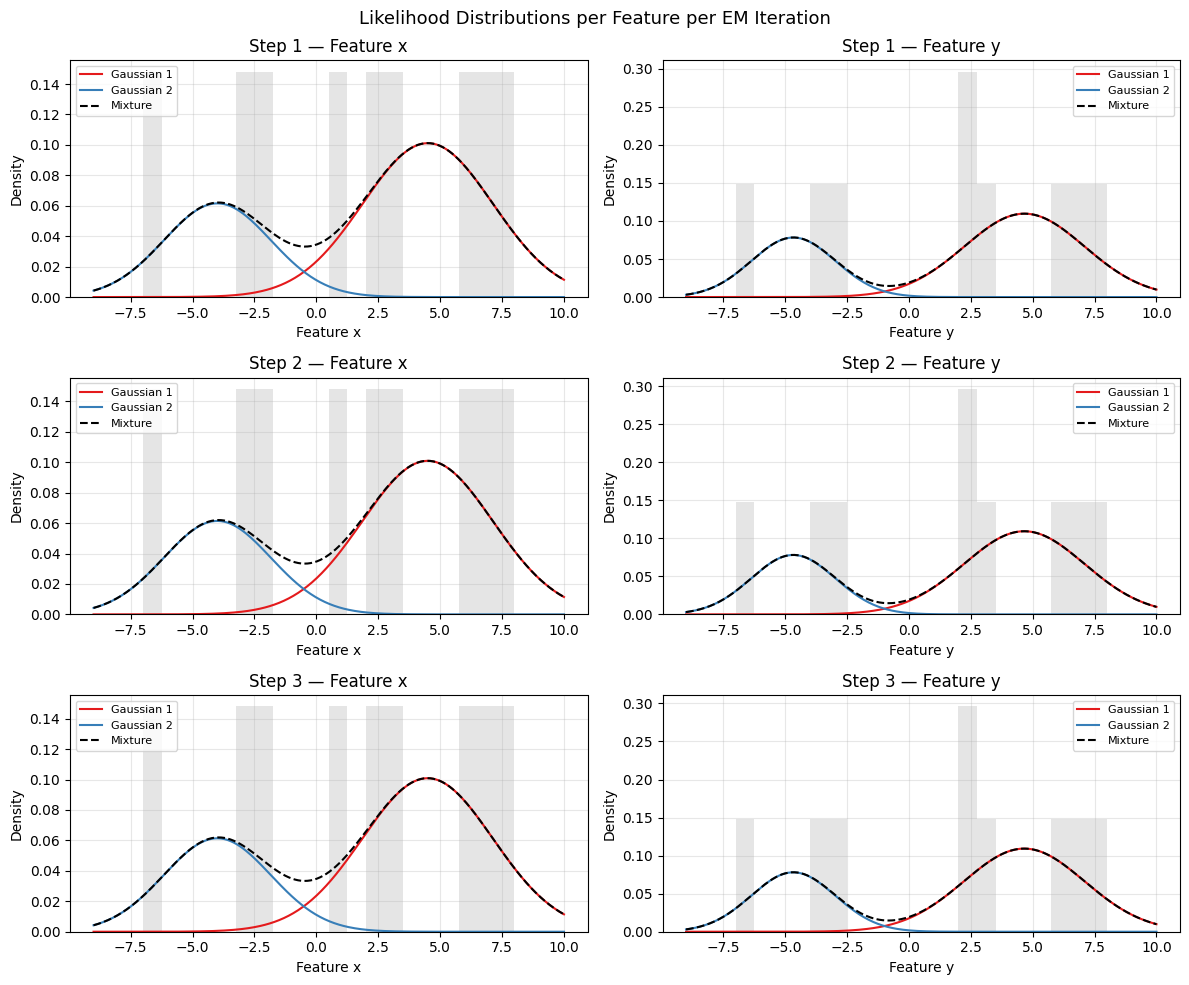

In [83]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))  # 3 iterations × 2 features

for idx, (step, mu_step, sigma_step, phi_step, _) in enumerate(history_2[1:]):  # skip step 0
    for feat_idx, feat_name in enumerate(["Feature x", "Feature y"]):
        ax = axes[idx][feat_idx]
        x_range = np.linspace(X[:, feat_idx].min() - 2, X[:, feat_idx].max() + 2, 300)

        for j in range(k_2):
            mean_j  = mu_step[j][feat_idx]
            std_j   = np.sqrt(sigma_step[j][feat_idx, feat_idx])  # marginal std
            weight_j = phi_step[j]
            y_vals  = weight_j * norm.pdf(x_range, mean_j, std_j)
            ax.plot(x_range, y_vals, label=f"Gaussian {j+1}", color=colors[j])

        # Total mixture
        total = sum(
            phi_step[j] * norm.pdf(x_range, mu_step[j][feat_idx],
                                   np.sqrt(sigma_step[j][feat_idx, feat_idx]))
            for j in range(k_2)
        )
        ax.plot(x_range, total, 'k--', label="Mixture", linewidth=1.5)
        ax.hist(X[:, feat_idx], bins=20, density=True, alpha=0.2, color='gray')
        ax.set_title(f"Step {step} — {feat_name}")
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Likelihood Distributions per Feature per EM Iteration", fontsize=13)
plt.tight_layout()
plt.show()

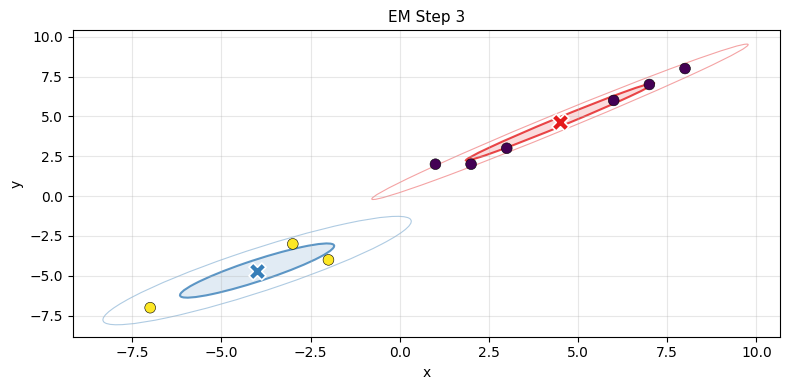

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex=True, sharey=True)
ax.scatter(X[:, 0], X[:, 1], c=labels_step, cmap='viridis',
               s=60, edgecolors='k', linewidths=0.4, zorder=3)
for j in range(k_2):
    color = colors[j % len(colors)]
    # Draw 1σ and 2σ confidence ellipses
    draw_confidence_ellipse(ax, mu_step[j], sigma_step[j],
                            n_std=1.0, color=color, alpha=0.15)
    # Mean marker
    ax.scatter(mu_step[j, 0], mu_step[j, 1],
                marker='X', s=150, color=color,
                edgecolors='white', linewidths=1.2, zorder=4)

ax.set_title(f"EM Step {step}", fontsize=11)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

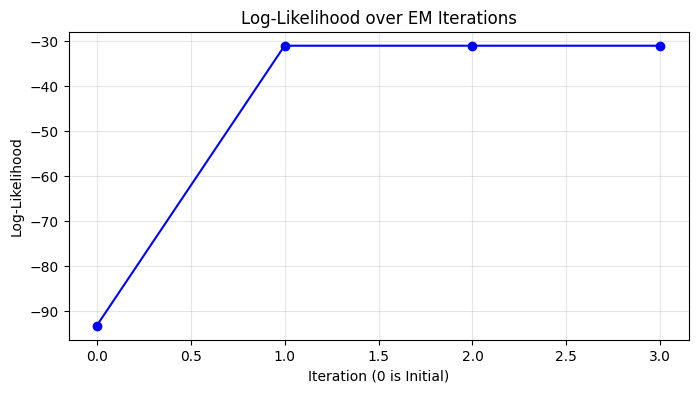

Log-Likelihoods: [np.float64(-93.2792182074559), np.float64(-31.126519501428586), np.float64(-31.126215596107293), np.float64(-31.126211819951166)]


In [85]:
# Plotting
plt.figure(figsize=(8, 4))
plt.plot(range(len(log_likelihoods_2)), log_likelihoods_2, marker='o', linestyle='-', color='b')
plt.title("Log-Likelihood over EM Iterations")
plt.xlabel("Iteration (0 is Initial)")
plt.ylabel("Log-Likelihood")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Log-Likelihoods: {log_likelihoods_2}")

#### Part 4 
Plot the log likelihood of the model given the data after each EM step. Compare the log
likelihood between using two mixtures and three mixtures. Which one has the better likelihood?
(3 points)

In [86]:
# Create a grid for the plot
x_range = np.linspace(-10, 10, 100)
y_range = np.linspace(-10, 10, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
pos = np.dstack((X_grid, Y_grid))

def plot_marginal(phi, k, mu, sigma, feature_index, label):
    x_line = np.linspace(-10, 10, 500)
    total_pdf = np.zeros_like(x_line)
    
    plt.figure(figsize=(8, 4))
    for j in range(k):
        # Use mean and variance of specific feature
        m = mu[j][feature_index]
        s = np.sqrt(sigma[j][feature_index, feature_index])
        
        # Calculate weighted component
        component_pdf = phi[j] * (1/(s * np.sqrt(2*np.pi)) * np.exp(-0.5*((x_line-m)/s)**2))
        total_pdf += component_pdf
        plt.plot(x_line, component_pdf, '--', alpha=0.5, label=f'Comp {j+1} (Weighted)')

    plt.plot(x_line, total_pdf, 'r-', linewidth=2, label='Total GMM Likelihood')
    plt.scatter(X[:, feature_index], np.zeros(len(X)), c='black', marker='|', label='Data')
    plt.title(f"Likelihood Distribution for Feature: {label}")
    plt.legend()
    plt.show()

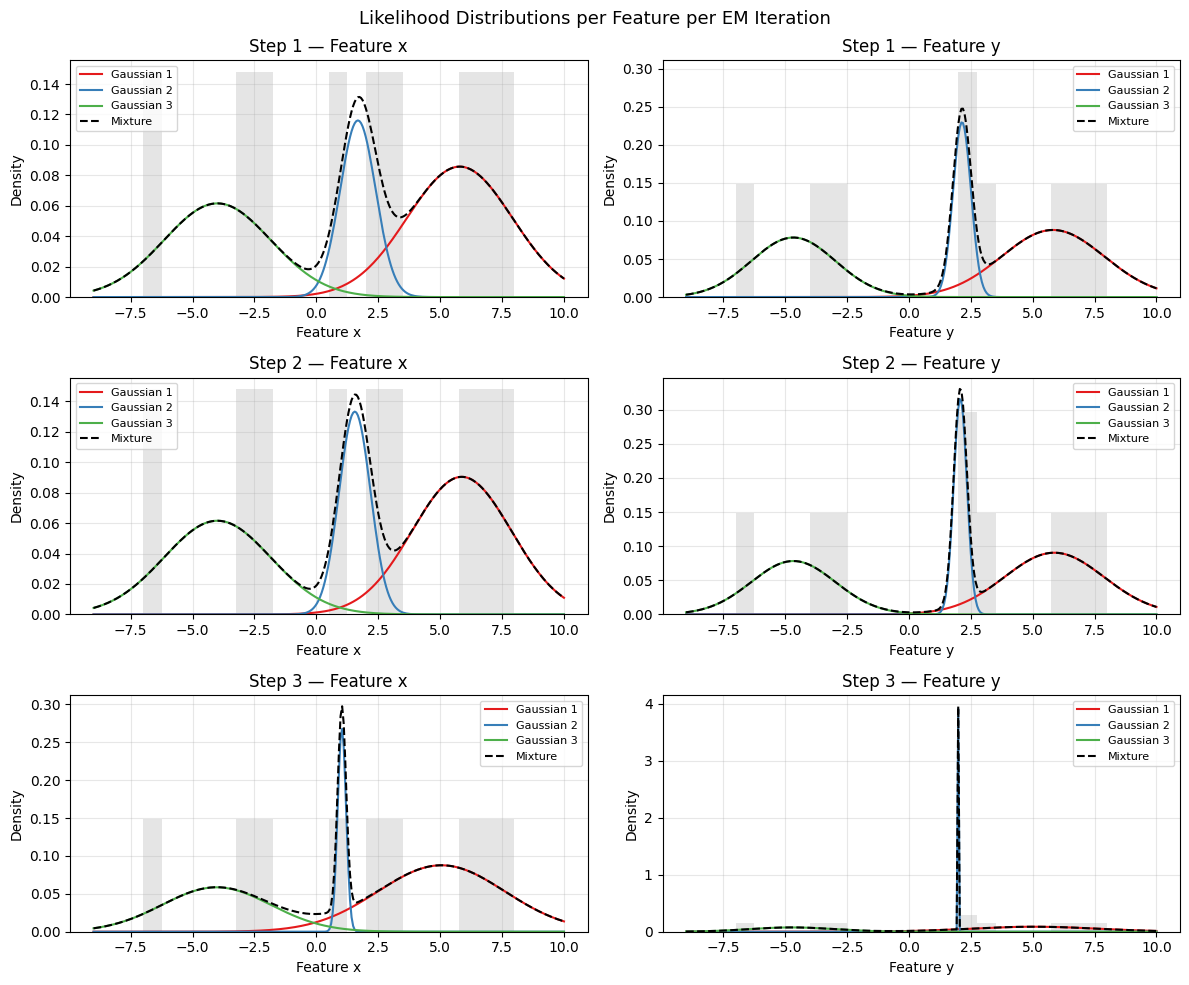

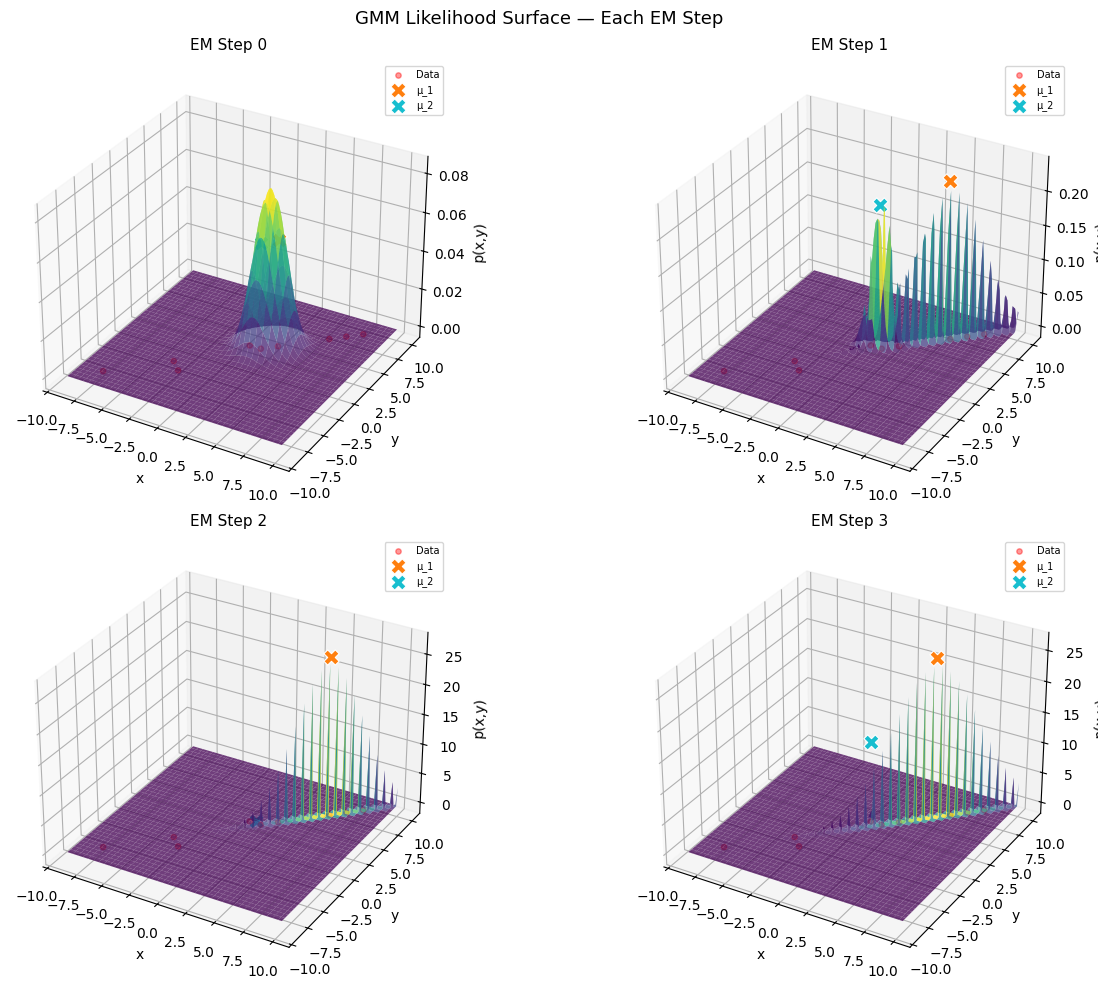

In [87]:
from scipy.stats import norm

fig, axes = plt.subplots(3, 2, figsize=(12, 10))  # 3 iterations × 2 features

for idx, (step, mu_step, sigma_step, phi_step, _) in enumerate(history[1:]):  # skip step 0
    for feat_idx, feat_name in enumerate(["Feature x", "Feature y"]):
        ax = axes[idx][feat_idx]
        x_range = np.linspace(X[:, feat_idx].min() - 2, X[:, feat_idx].max() + 2, 300)

        for j in range(k):
            mean_j  = mu_step[j][feat_idx]
            std_j   = np.sqrt(sigma_step[j][feat_idx, feat_idx])  # marginal std
            weight_j = phi_step[j]
            y_vals  = weight_j * norm.pdf(x_range, mean_j, std_j)
            ax.plot(x_range, y_vals, label=f"Gaussian {j+1}", color=colors[j])

        # Total mixture
        total = sum(
            phi_step[j] * norm.pdf(x_range, mu_step[j][feat_idx],
                                   np.sqrt(sigma_step[j][feat_idx, feat_idx]))
            for j in range(k)
        )
        ax.plot(x_range, total, 'k--', label="Mixture", linewidth=1.5)
        ax.hist(X[:, feat_idx], bins=20, density=True, alpha=0.2, color='gray')
        ax.set_title(f"Step {step} — {feat_name}")
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Likelihood Distributions per Feature per EM Iteration", fontsize=13)
plt.tight_layout()
plt.show()

x_min, x_max = X[:, 0].min() - 2, X[:, 0].max() + 2
y_min, y_max = X[:, 1].min() - 2, X[:, 1].max() + 2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 120),
                     np.linspace(y_min, y_max, 120))
pos = np.dstack((xx, yy))          # shape (120, 120, 2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                         subplot_kw={"projection": "3d"})
axes = axes.ravel()

for ax, (step, mu_step, sigma_step, phi_step, _) in zip(axes, history):
    Z = np.zeros(xx.shape)
    for j in range(k_2):
        Z += phi_step[j] * multivariate_normal(mu_step[j], sigma_step[j]).pdf(pos)

    ax.plot_surface(xx, yy, Z, cmap="viridis", alpha=0.75, edgecolor="none")

    # Data points projected onto z=0 plane
    ax.scatter(X[:, 0], X[:, 1],
               np.zeros(len(X)),
               c="red", s=15, alpha=0.4, zorder=5, label="Data")

    # Mean markers lifted slightly above the surface
    for j in range(k_2):
        z_at_mean = phi_step[j] * multivariate_normal(
            mu_step[j], sigma_step[j]).pdf(mu_step[j])
        ax.scatter(*mu_step[j], z_at_mean * 1.05,
                   marker="X", s=120,
                   color=["tab:orange", "tab:cyan"][j],
                   edgecolors="white", linewidths=0.8,
                   zorder=6, label=f"μ_{j+1}")

    ax.set_title(f"EM Step {step}", fontsize=11, pad=8)
    ax.set_xlabel("x", labelpad=4)
    ax.set_ylabel("y", labelpad=4)
    ax.set_zlabel("p(x,y)", labelpad=4)
    ax.view_init(elev=30, azim=-60)  
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")

plt.suptitle("GMM Likelihood Surface — Each EM Step", fontsize=13)
plt.tight_layout()
plt.show()

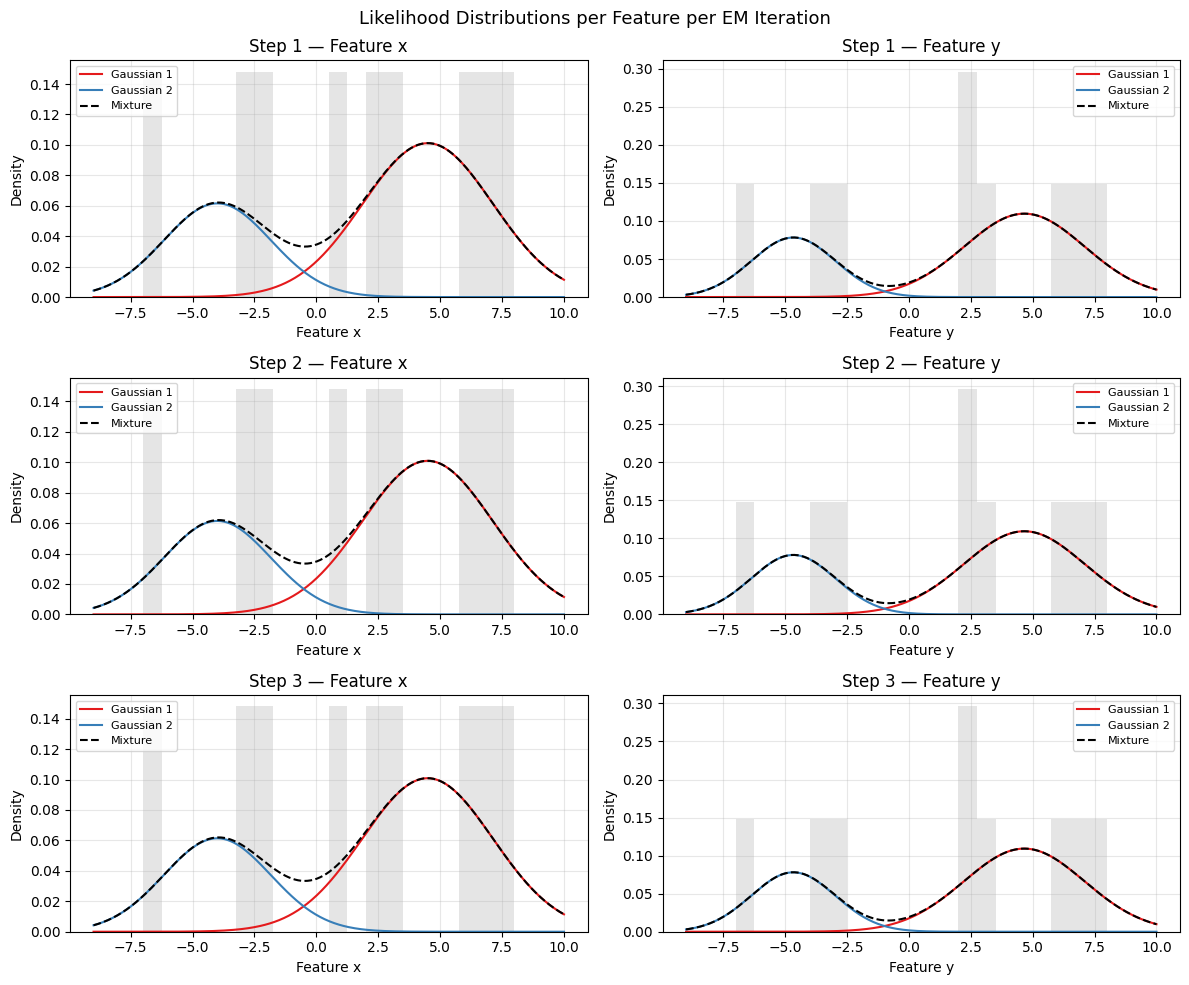

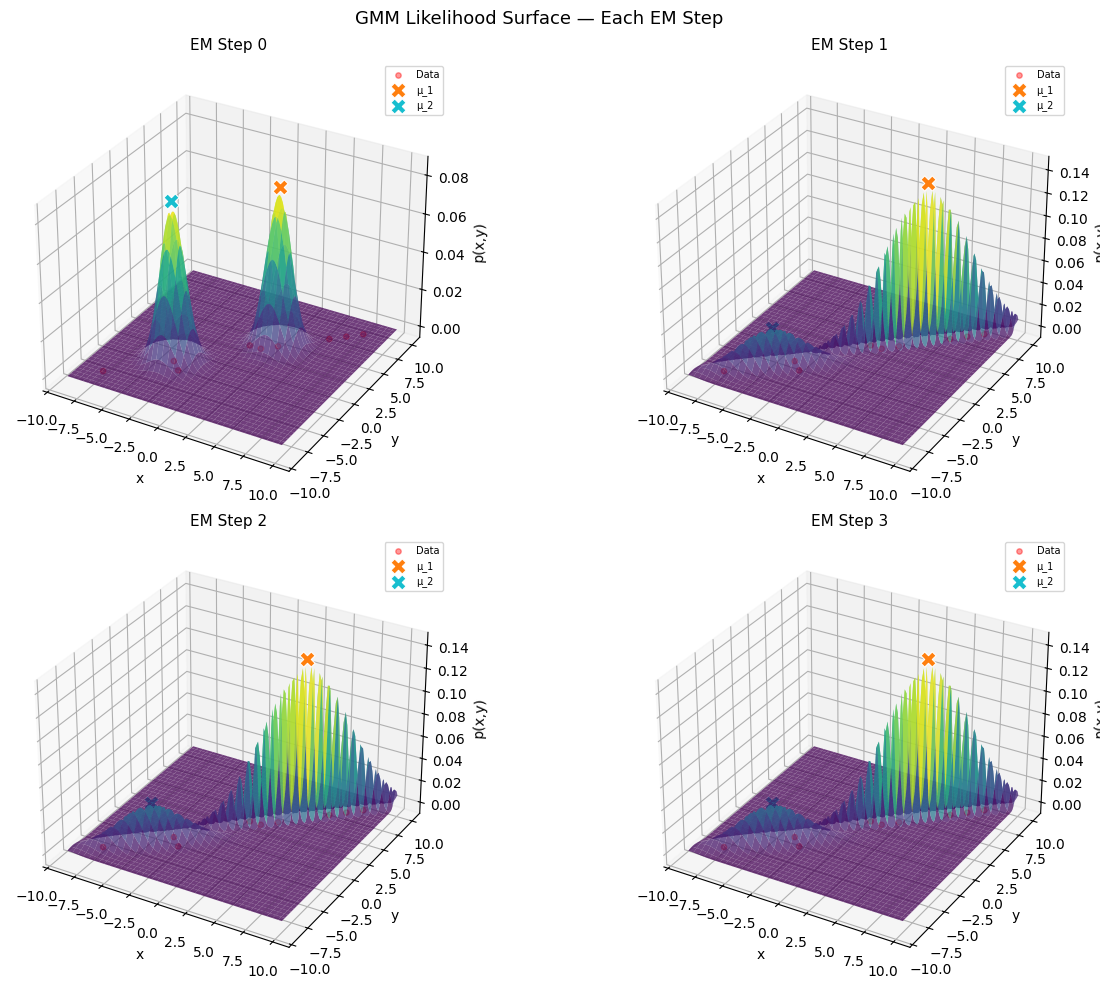

In [88]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))  # 3 iterations × 2 features

for idx, (step, mu_step, sigma_step, phi_step, _) in enumerate(history_2[1:]):  # skip step 0
    for feat_idx, feat_name in enumerate(["Feature x", "Feature y"]):
        ax = axes[idx][feat_idx]
        x_range = np.linspace(X[:, feat_idx].min() - 2, X[:, feat_idx].max() + 2, 300)

        for j in range(k_2):
            mean_j  = mu_step[j][feat_idx]
            std_j   = np.sqrt(sigma_step[j][feat_idx, feat_idx])  # marginal std
            weight_j = phi_step[j]
            y_vals  = weight_j * norm.pdf(x_range, mean_j, std_j)
            ax.plot(x_range, y_vals, label=f"Gaussian {j+1}", color=colors[j])

        # Total mixture
        total = sum(
            phi_step[j] * norm.pdf(x_range, mu_step[j][feat_idx],
                                   np.sqrt(sigma_step[j][feat_idx, feat_idx]))
            for j in range(k_2)
        )
        ax.plot(x_range, total, 'k--', label="Mixture", linewidth=1.5)
        ax.hist(X[:, feat_idx], bins=20, density=True, alpha=0.2, color='gray')
        ax.set_title(f"Step {step} — {feat_name}")
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Likelihood Distributions per Feature per EM Iteration", fontsize=13)
plt.tight_layout()
plt.show()

x_min, x_max = X[:, 0].min() - 2, X[:, 0].max() + 2
y_min, y_max = X[:, 1].min() - 2, X[:, 1].max() + 2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 120),
                     np.linspace(y_min, y_max, 120))
pos = np.dstack((xx, yy))          # shape (120, 120, 2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                         subplot_kw={"projection": "3d"})
axes = axes.ravel()

for ax, (step, mu_step, sigma_step, phi_step, _) in zip(axes, history_2):
    Z = np.zeros(xx.shape)
    for j in range(k_2):
        Z += phi_step[j] * multivariate_normal(mu_step[j], sigma_step[j]).pdf(pos)

    ax.plot_surface(xx, yy, Z, cmap="viridis", alpha=0.75, edgecolor="none")

    # Data points projected onto z=0 plane
    ax.scatter(X[:, 0], X[:, 1],
               np.zeros(len(X)),
               c="red", s=15, alpha=0.4, zorder=5, label="Data")

    # Mean markers lifted slightly above the surface
    for j in range(k_2):
        z_at_mean = phi_step[j] * multivariate_normal(
            mu_step[j], sigma_step[j]).pdf(mu_step[j])
        ax.scatter(*mu_step[j], z_at_mean * 1.05,
                   marker="X", s=120,
                   color=["tab:orange", "tab:cyan"][j],
                   edgecolors="white", linewidths=0.8,
                   zorder=6, label=f"μ_{j+1}")

    ax.set_title(f"EM Step {step}", fontsize=11, pad=8)
    ax.set_xlabel("x", labelpad=4)
    ax.set_ylabel("y", labelpad=4)
    ax.set_zlabel("p(x,y)", labelpad=4)
    ax.view_init(elev=30, azim=-60)  
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")

plt.suptitle("GMM Likelihood Surface — Each EM Step", fontsize=13)
plt.tight_layout()
plt.show()


EM Algorithm Convergence Comparison
| Iteration | 3-Gaussian (Log-Likelihood) | 2-Gaussian (Log-Likelihood) |
|:---:|:---:|:---:|
| 0 | -93.1739 | -93.2792 |
| 1 | -25.1523 | -31.1265 |
| 2 | -2.1822 | -31.1262 |
| 3 | 6.1864 | -31.1262 |

* **Optimization:** The 3-Gaussian model shows a much higher final Log-Likelihood, indicating a better fit to the underlying data distribution.
* **Convergence:** The 2-Gaussian model reaches a plateau by the 3rd step, while the 3-Gaussian model is still climbing significantly, suggesting a more complex optimization landscape.

`ANSWER` : The 3-mixture model achieves a higher raw log-likelihood, but the result is statistically invalid due to covariance collapse. The 2-mixture model is the better solution for this dataset it converges stably and the two components meaningfully capture the two clusters in the data.